In [1]:
import importlib
import sys
import torch
import numpy as np
from collections import Counter
import pandas as pd

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader, EventLogPerturbationPreprocess

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/helpdesk.csv'

result_name = 'helpdesk_all'

cat_dynamic = ['Activity', 'Resource']
# cat_static =  ['VariantIndex', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']
cat_static =  ['seriousness', 'product', 'responsible_section', 'service_level', 'service_type', 'support_section', 'workgroup']

num_dynamic = ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day']
num_dyn_log = []
num_static = []

min_suffix_size = 5

event_log_properties = {# case id
                        'case_name' : 'CaseID',
                        # activit
                        'concept_name' : 'Activity',
                        # time values and computaitons
                        'timestamp_name' : 'CompleteTimestamp',
                        'date_format' : '%Y/%m/%d %H:%M:%S.%f',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # trian and test split
                        'train_validation_size' : 0.15,
                        'test_validation_size' : 0.2,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## create dataframe of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
# raw_data = pref_adopt_dataframe.get_raw_dataframe()
# raw_data

In [5]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,seriousness,product,responsible_section,service_level,service_type,support_section,workgroup
0,Case 10,1,[Assign seriousness],[Value 2],[0.0],[nan],[2.0],[31820.0],Value 1,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
1,Case 10,2,"[Assign seriousness, Take in charge ticket]","[Value 2, Value 2]","[0.0, 3196606.0]","[nan, 3196606.0]","[2.0, 4.0]","[31820.0, 31626.0]",Value 1,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
2,Case 10,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 2, Value 2, Value 2]","[0.0, 3196606.0, 3196613.0]","[nan, 3196606.0, 7.0]","[2.0, 4.0, 4.0]","[31820.0, 31626.0, 31633.0]",Value 1,Value 3,Value 2,Value 3,Value 1,Value 2,Value 3
3,Case 100,1,[Assign seriousness],[Value 1],[0.0],[nan],[4.0],[37517.0],Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
4,Case 100,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 9]","[0.0, 1036724.0]","[nan, 1036724.0]","[4.0, 2.0]","[37517.0, 37441.0]",Value 1,Value 1,Value 1,Value 2,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10936,Case 993,4,"[Assign seriousness, Take in charge ticket, Wa...","[Value 8, Value 8, Value 2, Value 2]","[0.0, 235.0, 1200632.0, 1379474.0]","[nan, 235.0, 1200397.0, 178842.0]","[0.0, 0.0, 0.0, 2.0]","[40283.0, 40518.0, 31315.0, 37357.0]",Value 1,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
10937,Case 993,5,"[Assign seriousness, Take in charge ticket, Wa...","[Value 8, Value 8, Value 2, Value 2, Value 2]","[0.0, 235.0, 1200632.0, 1379474.0, 1379486.0]","[nan, 235.0, 1200397.0, 178842.0, 12.0]","[0.0, 0.0, 0.0, 2.0, 2.0]","[40283.0, 40518.0, 31315.0, 37357.0, 37369.0]",Value 1,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
10938,Case 996,1,[Assign seriousness],[Value 8],[0.0],[nan],[3.0],[49903.0],Value 1,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
10939,Case 996,2,"[Assign seriousness, Take in charge ticket]","[Value 8, Value 6]","[0.0, 325091.0]","[nan, 325091.0]","[3.0, 0.0]","[49903.0, 29394.0]",Value 1,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2


In [6]:
train_pref_df.to_csv('../../../../encoded_data/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [7]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,seriousness,product,responsible_section,service_level,service_type,support_section,workgroup
0,Case 1,1,[Assign seriousness],[Value 1],[0.0],[nan],[1.0],[53417.0],Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
1,Case 1,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 1]","[0.0, 44.0]","[nan, 44.0]","[1.0, 1.0]","[53417.0, 53461.0]",Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
2,Case 1,3,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2]","[0.0, 44.0, 259959.0]","[nan, 44.0, 259915.0]","[1.0, 1.0, 4.0]","[53417.0, 53461.0, 54176.0]",Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
3,Case 1,4,"[Assign seriousness, Take in charge ticket, Ta...","[Value 1, Value 1, Value 2, Value 1]","[0.0, 44.0, 259959.0, 1371849.0]","[nan, 44.0, 259915.0, 1111890.0]","[1.0, 1.0, 4.0, 3.0]","[53417.0, 53461.0, 54176.0, 42866.0]",Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
4,Case 1005,1,[Assign seriousness],[Value 8],[0.0],[nan],[2.0],[30914.0],Value 1,Value 2,Value 1,Value 1,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,Case 981,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 1, Value 1, Value 1]","[0.0, 9.0, 164583.0]","[nan, 9.0, 164574.0]","[1.0, 1.0, 3.0]","[38550.0, 38559.0, 30333.0]",Value 1,Value 4,Value 1,Value 2,Value 1,Value 1,Value 1
2494,Case 981,4,"[Assign seriousness, Take in charge ticket, Re...","[Value 1, Value 1, Value 1, Value 1]","[0.0, 9.0, 164583.0, 164584.0]","[nan, 9.0, 164574.0, 1.0]","[1.0, 1.0, 3.0, 3.0]","[38550.0, 38559.0, 30333.0, 30334.0]",Value 1,Value 4,Value 1,Value 2,Value 1,Value 1,Value 1
2495,Case 999,1,[Assign seriousness],[Value 1],[0.0],[nan],[1.0],[57997.0],Value 1,Value 3,Value 1,Value 2,Value 2,Value 1,Value 4
2496,Case 999,2,"[Assign seriousness, Take in charge ticket]","[Value 1, Value 12]","[0.0, 1107043.0]","[nan, 1107043.0]","[1.0, 0.0]","[57997.0, 41840.0]",Value 1,Value 3,Value 1,Value 2,Value 2,Value 1,Value 4


In [8]:
val_pref_df.to_csv('../../../../encoded_data/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [9]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,CaseID,prefix_length,Activity,Resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,seriousness,product,responsible_section,service_level,service_type,support_section,workgroup
0,Case 1016,1,[Assign seriousness],[Value 8],[0.0],[nan],[2.0],[27781.0],Value 1,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
1,Case 1016,2,"[Assign seriousness, Take in charge ticket]","[Value 8, Value 8]","[0.0, 149.0]","[nan, 149.0]","[2.0, 2.0]","[27781.0, 27930.0]",Value 1,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
2,Case 1016,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 8, Value 8, Value 16]","[0.0, 149.0, 26072.0]","[nan, 149.0, 25923.0]","[2.0, 2.0, 2.0]","[27781.0, 27930.0, 53853.0]",Value 1,Value 3,Value 1,Value 2,Value 2,Value 1,Value 2
3,Case 102,1,[Assign seriousness],[Value 4],[0.0],[nan],[0.0],[32969.0],Value 1,Value 3,Value 1,Value 1,Value 1,Value 1,Value 1
4,Case 102,2,"[Assign seriousness, Take in charge ticket]","[Value 4, Value 4]","[0.0, 28.0]","[nan, 28.0]","[0.0, 0.0]","[32969.0, 32997.0]",Value 1,Value 3,Value 1,Value 1,Value 1,Value 1,Value 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3324,Case 997,3,"[Assign seriousness, Take in charge ticket, Re...","[Value 1, Value 13, Value 13]","[0.0, 258637.0, 871435.0]","[nan, 258637.0, 612798.0]","[4.0, 0.0, 0.0]","[48912.0, 48349.0, 56347.0]",Value 1,Value 2,Value 1,Value 2,Value 1,Value 1,Value 1
3325,Case 998,1,[Assign seriousness],[Value 9],[0.0],[nan],[4.0],[43033.0],Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
3326,Case 998,2,"[Assign seriousness, Take in charge ticket]","[Value 9, Value 2]","[0.0, 25.0]","[nan, 25.0]","[4.0, 4.0]","[43033.0, 43058.0]",Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1
3327,Case 998,3,"[Assign seriousness, Take in charge ticket, Wait]","[Value 9, Value 2, Value 9]","[0.0, 25.0, 338294.0]","[nan, 25.0, 338269.0]","[4.0, 4.0, 1.0]","[43033.0, 43058.0, 35727.0]",Value 1,Value 1,Value 1,Value 1,Value 1,Value 1,Value 1


In [10]:
test_pref_df.to_csv('../../../../encoded_data/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## compute markings: petri net replay of prefixes

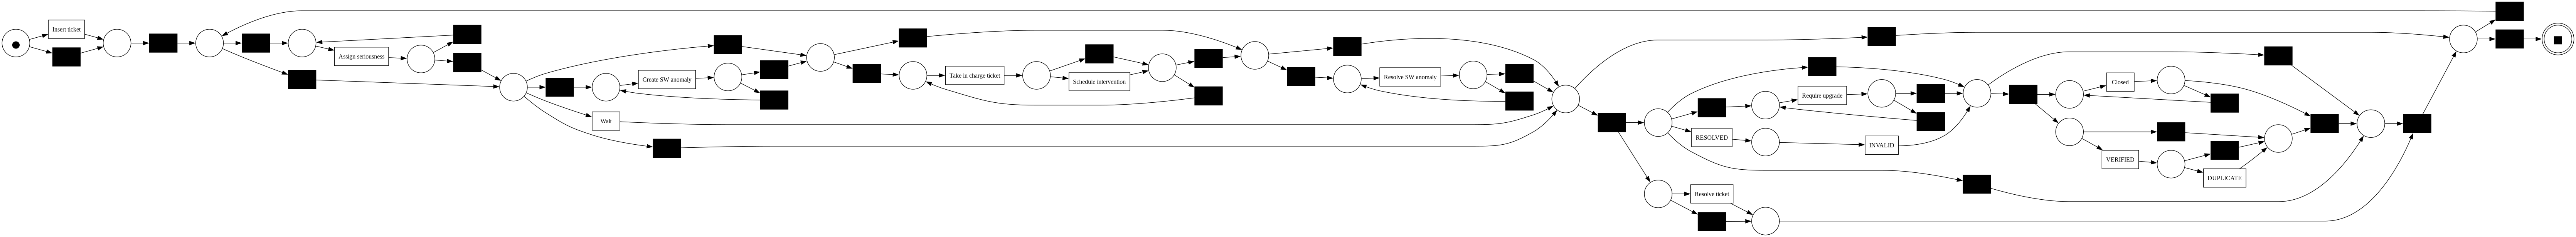

In [11]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="CaseID", activity_col="Activity", timestamp_col="CompleteTimestamp", resource_col="Resource")
net, im, fm = miner.discover_petri_net(visulaize=True, store_loc_file_path='../../../../encoded_data/prefix_for_replay/petri_net/helpdesk.png')

In [12]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="Activity")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  10941


,marking,count
0,[p_19],3320
1,[p_9],3196
2,"[p_26, p_25]",3193
3,[p_11],953
4,[p_4],76
5,"[p_24, p_30]",75
6,"[p_30, p_25]",54
7,[p_14],48
8,"[p_25, p_38, p_36]",10
9,[p_22],9


In [13]:
# train set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="Activity")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  2498


,marking,count
0,[p_9],747
1,[p_19],743
2,"[p_26, p_25]",725
3,[p_11],223
4,"[p_24, p_30]",20
5,[p_4],14
6,"[p_30, p_25]",13
7,[p_14],7
8,[p_18],3
9,[p_22],2


In [14]:
# train set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="Activity")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  3329


,marking,count
0,[p_19],996
1,[p_9],995
2,"[p_26, p_25]",978
3,[p_11],279
4,[p_4],28
5,"[p_24, p_30]",20
6,[p_14],12
7,"[p_30, p_25]",9
8,"[p_25, p_38, p_36]",6
9,[p_22],2


## store datasets and credentials for dnn

In [15]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [16]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/2977 [00:00<?, ?it/s]

Resource:   0%|          | 0/2977 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/2977 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/2977 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/2977 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/2977 [00:00<?, ?it/s]

static categorical:   0%|          | 0/10941 [00:00<?, ?it/s]

In [17]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)
print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)
print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())
print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())
print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())
print("Zero padds: ", train_set.zero_padding[0:3])
print("EOS padds: ", train_set.eos_padding[0:3])
print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:5])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('seriousness', 2, {'Value

In [18]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/687 [00:00<?, ?it/s]

Resource:   0%|          | 0/687 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/687 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/687 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/687 [00:00<?, ?it/s]

static categorical:   0%|          | 0/2498 [00:00<?, ?it/s]

In [19]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)
print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)
print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())
print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())
print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())
# print(train_dataset.zero_padding[0:5])
# print(train_dataset.eos_padding[0:5])
print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:5])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('seriousness', 2, {'Value

In [20]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/2 [00:00<?, ?it/s]

Activity:   0%|          | 0/916 [00:00<?, ?it/s]

Resource:   0%|          | 0/916 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

case_elapsed_time:   0%|          | 0/916 [00:00<?, ?it/s]

event_elapsed_time:   0%|          | 0/916 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/916 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/916 [00:00<?, ?it/s]

static categorical:   0%|          | 0/3329 [00:00<?, ?it/s]

In [21]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)
print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)
print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())
print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())
print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print(train_dataset.zero_padding[0:5])
# print(train_dataset.eos_padding[0:5])
print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:5])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('seriousness', 2, {'Value